# AG News: de una hipótesis a una comparación medible

Adaptamos `bert-base-uncased` a cuatro categorías de noticias en inglés: World, Sports, Business y Sci/Tech.

**Hipótesis:** ajustar BERT completo podría mejorar macro-F1, pero consumir más tiempo y memoria.
La hipótesis no decide qué modelo entregamos: lo decide validación.

Compararemos **BERT congelado + clasificador lineal** frente a **ajuste completo**. Ambos usan exactamente
la misma arquitectura (`BertForSequenceClassification`, representación CLS procesada por el pooler y cabeza lineal).
El MLP del borrador se sustituye por una cabeza lineal para aislar mejor el efecto del método de adaptación.
Las cabezas arrancan con la misma semilla y los lotes siguen el mismo orden en ambas alternativas.

El código compartido está en `src/agnews_experiment.py`; este notebook ejecuta y conserva la evidencia.

## 1. Entorno
Abre este notebook desde una copia completa del repositorio. Usa Python 3.12 y `requirements-agnews.txt`.
En Colab, selecciona GPU y sube/clona el repositorio antes de ejecutar.
En Windows con NVIDIA instala primero `torch==2.6.0` desde el índice cu124 indicado en `AGNEWS_GUIDE.md`.

In [1]:
from pathlib import Path
import sys
import os
import json

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "src" / "agnews_experiment.py").exists()), None)
if ROOT is None:
    raise RuntimeError("Abre el notebook dentro del repositorio completo bert-adaptation")
sys.path.insert(0, str(ROOT / "src"))
print("Repositorio:", ROOT)
print("Python:", sys.executable)
# En un entorno nuevo, ejecutar una vez y reiniciar el kernel:
# %pip install -r {ROOT / "requirements-agnews.txt"}

Repositorio: C:\Users\IGNITER\Downloads\bert-adaptation
Python: C:\Users\IGNITER\Documents\ChatGPT\Cosas Escuela 2\.venv-agnews\Scripts\python.exe


## 2. Configuración y separación de datos
- 12,000 ejemplos para aprender; 2,000 de validación para elegir; 2,000 de prueba para evaluación final.
- Los dos primeros grupos proceden del train oficial; prueba procede del test oficial.
- Muestreo estratificado y exclusión de duplicados exactos normalizados entre grupos.
- Tres épocas, semilla 42, longitud máxima 128, microbatch 8 y acumulación 4 (batch efectivo 32).
- Cabeza: LR 1e-3; cuerpo, cuando se entrena: LR 2e-5. Ambas alternativas usan warmup y decaimiento lineal.

El modo `SMOKE=True` usa solo 32/16/16 ejemplos y una época para comprobar el recorrido completo.
**Sus métricas no son resultados finales.** Cada ejecución crea una carpeta nueva, sin sobrescribir resultados.

In [2]:
from datetime import datetime
from dataclasses import asdict
from agnews_experiment import Config, run_experiment
import torch

SMOKE = os.environ.get("AGNEWS_SMOKE", "0") == "1"
cfg = Config(train_size=32, val_size=16, test_size=16, epochs=1, smoke=True) if SMOKE else Config()
RUN = ROOT / "runs" / (os.environ.get("AGNEWS_RUN_NAME") or
                       (("smoke_" if SMOKE else "agnews_") + datetime.now().strftime("%Y%m%d_%H%M%S")))
print(asdict(cfg))
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No disponible; se usará CPU")
print("Salida:", RUN)

C:\Users\IGNITER\Documents\ChatGPT\Cosas Escuela 2\.venv-agnews\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'seed': 42, 'train_size': 32, 'val_size': 16, 'test_size': 16, 'epochs': 1, 'micro_batch': 8, 'accumulation': 4, 'max_length': 128, 'head_lr': 0.001, 'backbone_lr': 2e-05, 'weight_decay': 0.01, 'model_id': 'google-bert/bert-base-uncased', 'dataset_id': 'fancyzhx/ag_news', 'model_revision': None, 'dataset_revision': None, 'smoke': True}
GPU: NVIDIA GeForce RTX 4060 Ti
Salida: C:\Users\IGNITER\Downloads\bert-adaptation\runs\smoke_verified_gpu


## 3. Entrenar y evaluar
La pérdida mide el error que intentamos reducir. Accuracy cuenta predicciones correctas;
macro-F1 promedia el F1 de las cuatro categorías con el mismo peso.

El experimento conserva el checkpoint con mayor **macro-F1 de validación** de cada alternativa.
Luego elige el método usando ese mismo criterio (empate exacto: menos parámetros entrenables).
La decisión se guarda antes de predecir sobre prueba. Se evalúan ambas alternativas en prueba para documentar la comparación.

En feature-based, BERT permanece en `eval()` incluso mientras la cabeza aprende: pesos y dropout del extractor
quedan fijos. Se comprueba por hash que los pesos congelados no cambiaron.
No se precalculan embeddings: el tiempo incluye pasar los textos por BERT en cada época.
La salida muestra el avance cada 200 microbatches y los resultados al terminar cada época.

In [3]:
comparison = run_experiment(cfg, RUN)
display(comparison)

{"python": "3.12.14", "platform": "Windows-10-10.0.19045-SP0", "torch_cuda": "12.4", "device": "cuda", "gpu": "NVIDIA GeForce RTX 4060 Ti", "precision": "bf16", "versions": {"torch": "2.6.0+cu124", "transformers": "4.49.0", "datasets": "3.3.2", "numpy": "2.2.3", "scikit-learn": "1.6.1", "huggingface-hub": "0.29.3"}}

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating train split:   1%|          | 1000/120000 [00:00<00:15, 7751.97 examples/s]

Generating train split: 100%|██████████| 120000/120000 [00:00<00:00, 579714.10 examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

...

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at google-bert/bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


full_finetuning {"epoch": 1, "train_loss": 1.4483642578125, "train_seconds": 0.6289170999953058, "validation_seconds": 0.03835540000000037, "val_loss": 1.36376953125, "val_accuracy": 0.25, "val_macro_f1": 0.1}


Matplotlib is building the font cache; this may take a moment.


COMPLETE C:\Users\IGNITER\Downloads\bert-adaptation\runs\smoke_verified_gpu winner: feature_based


,method,trainable_parameters,total_parameters,best_epoch,best_val_macro_f1,train_seconds,peak_allocated_gpu_bytes,frozen_backbone_verified,test_loss,test_accuracy,test_macro_f1,selected
0,feature_based,3076,109485316,1,0.105263,2.982261,538779648,True,1.369629,0.25,0.1,True
1,full_finetuning,109485316,109485316,1,0.100000,0.628917,2294483968,False,1.381836,0.25,0.1,False


## 4. Interpretar resultados y curvas
Compara validación con entrenamiento. Menor pérdida de entrenamiento no garantiza mejores resultados en textos nuevos.
Una sola semilla no demuestra superioridad estadística: interpreta con cautela diferencias pequeñas (la tarea advierte variaciones de 1–3 puntos).
Los tiempos de entrenamiento excluyen validación y guardado de checkpoints; estos son experimentos con el mismo hardware.

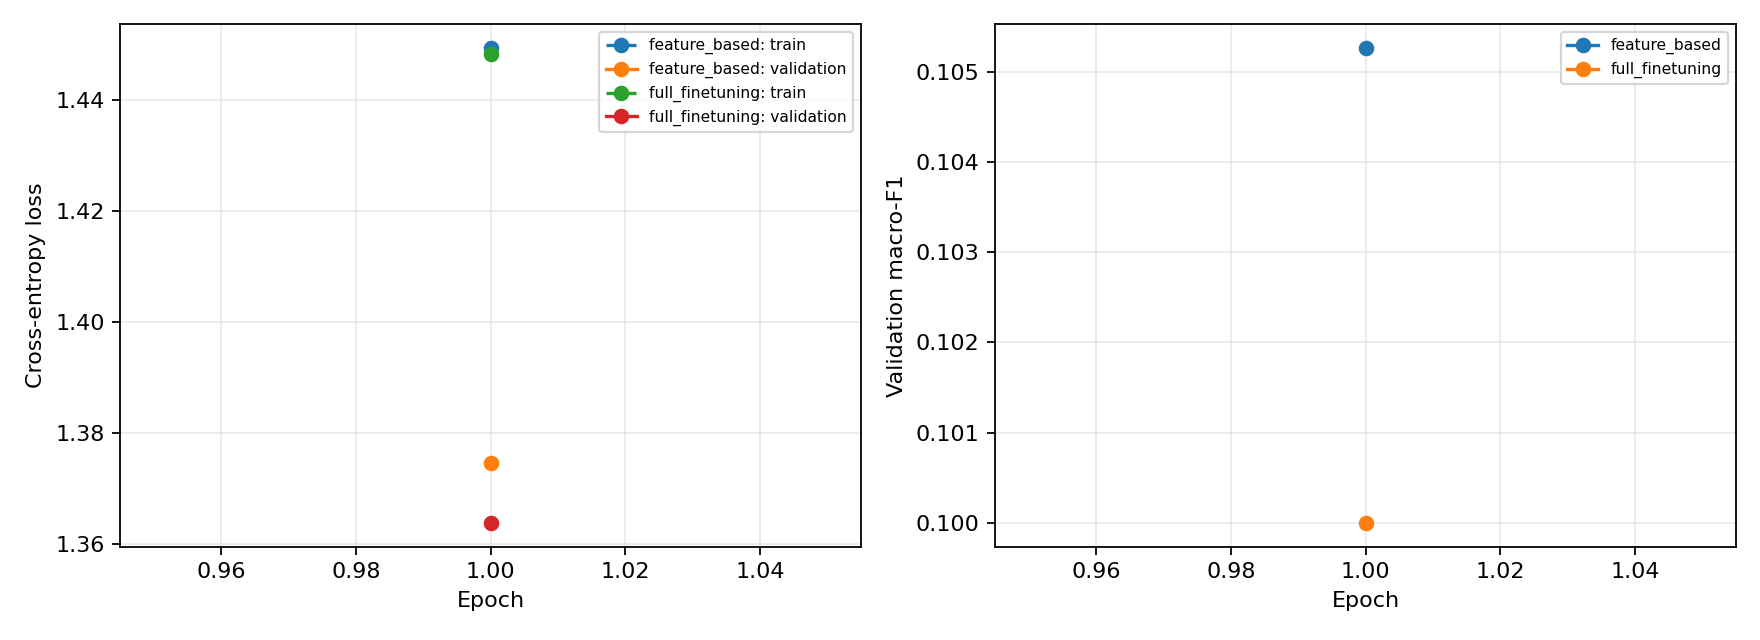

# AG News: resultados medidos

PRUEBA TECNICA: no usar estas cifras como resultados finales.

Equipo: NVIDIA GeForce RTX 4060 Ti; precision: bf16.
Datos: 32 entrenamiento / 16 validacion / 16 prueba; semilla 42.
Misma arquitectura BERT + pooler + clasificador lineal para aislar el efecto de congelar o ajustar el cuerpo.
Los tiempos incluyen el forward de BERT en cada epoca; no hay cache de embeddings.

| Metodo | Epoca elegida | F1 validacion | Accuracy prueba | F1 prueba | Entrenamiento (s) |
|---|---:|---:|---:|---:|---:|
| feature_based | 1 | 0.1053 | 0.2500 | 0.1000 | 3.0 |
| full_finetuning | 1 | 0.1000 | 0.2500 | 0.1000 | 0.6 |

Seleccion por validacion: **feature_based**. Diferencia de F1: 0.0053.
Una semilla no permite afirmar superioridad estadistica; diferencias pequenas pueden depender del azar.
Se evaluaron los mejores checkpoints de ambas alternativas en prueba despues de fijar la seleccion.
No se afirma una causa linguistica de las diferencias sin analizar ejemplos y realizar experimentos adicionales.

Evidencia: config.json, environment.json, splits.json, selection.json, comparison.csv, historiales por epoca y test_predictions.jsonl.
Los resultados de NER, POS y QA del reporte anterior siguen pendientes de verificacion.


Método seleccionado: feature_based


In [4]:
from IPython.display import Image, Markdown, display
display(Image(filename=str(RUN / "learning_curves.png")))
display(Markdown((RUN / "RESULTS.md").read_text(encoding="utf-8")))
selection = json.loads((RUN / "selection.json").read_text(encoding="utf-8"))
print("Método seleccionado:", selection["winner"])

## 5. Examinar errores
Una cifra no explica por sí sola por qué falla el modelo. Revisa ejemplos y la matriz de confusión.
Las filas de la matriz son clases reales y las columnas predicciones. No ajustes hiperparámetros con estos errores de prueba;
para iterar utiliza ejemplos de validación y conserva otra evaluación final independiente.

In [5]:
import pandas as pd
from agnews_experiment import LABELS
for method in comparison["method"]:
    scores = json.loads((RUN / method / "test_metrics.json").read_text(encoding="utf-8"))
    print(method)
    display(pd.DataFrame(scores["confusion_matrix"], index=LABELS, columns=LABELS))
    predictions = pd.read_json(RUN / method / "test_predictions.jsonl", lines=True)
    errors = predictions[predictions.reference != predictions.prediction].copy()
    errors["reference"] = errors["reference"].map(dict(enumerate(LABELS)))
    errors["prediction"] = errors["prediction"].map(dict(enumerate(LABELS)))
    display(errors.head(5))

feature_based


,World,Sports,Business,Sci/Tech
World,4,0,0,0
Sports,4,0,0,0
Business,4,0,0,0
Sci/Tech,4,0,0,0


,source_row,text,reference,prediction
0,7450,Mass. auto rates to stay fairly steady next ye...,Business,World
1,7449,UTC buys Kidde for 1.4bn UK fire equipment man...,Business,World
2,518,Martian Weather Blamed for Loss of Beagle 2 De...,Sci/Tech,World
3,6374,Here's the catch: Branch is back Deion Branch ...,Sports,World
5,4815,"Blame player, not game It was like nothing you...",Sci/Tech,World


full_finetuning


,World,Sports,Business,Sci/Tech
World,4,0,0,0
Sports,4,0,0,0
Business,4,0,0,0
Sci/Tech,4,0,0,0


,source_row,text,reference,prediction
0,7450,Mass. auto rates to stay fairly steady next ye...,Business,World
1,7449,UTC buys Kidde for 1.4bn UK fire equipment man...,Business,World
2,518,Martian Weather Blamed for Loss of Beagle 2 De...,Sci/Tech,World
3,6374,Here's the catch: Branch is back Deion Branch ...,Sports,World
5,4815,"Blame player, not game It was like nothing you...",Sci/Tech,World


## 6. Comprobar la exportación local
La ejecución final exporta el ganador con su tokenizer, nombres de etiquetas y model card.
En smoke no se genera un modelo entregable. Cargar el checkpoint nuevamente verifica que se puede reutilizar.
Publicar en Hugging Face es un paso posterior: todavía no se afirma que el repositorio exista o que tenga permisos concedidos.

In [6]:
from transformers import pipeline
if not SMOKE:
    classifier = pipeline("text-classification", model=str(RUN / "delivered_model_agnews"), device=-1)
    display(classifier([
        "The team won the championship after scoring in the final minute.",
        "Researchers announced a new computer chip for artificial intelligence."
    ]))
else:
    print("Smoke completado. Ejecuta después SMOKE=False para producir resultados entregables.")

Smoke completado. Ejecuta después SMOKE=False para producir resultados entregables.